# predic_consumo_agua_v10

Experimento complementario para comparar los modelos predictivos con modelos triviales de referencia o baselines. El objetivo es determinar si XGBoost y los modelos lineales reducen realmente el error frente a referencias simples, usando las mismas observaciones y respetando el orden temporal.

Este notebook no modifica los notebooks `predic_consumo_agua.ipynb` ni las versiones `v2` a `v9`. No se realiza commit ni push desde este experimento.


## 1. Criterio metodologico

La base utilizada es `df_consumo_bime_clima_v3.xlsx`, con 596 registros y unidad de analisis localidad-ano-bimestre. La variable objetivo es `consumo_promedio`. Los baselines se calculan siempre en escala original y solo con informacion historica permitida. Para 2023 se usa historial 2020-2022; para 2024 se usa historial 2020-2023; y en origen movil se usa la ventana expansiva definida en v8.

Los baselines implementados son media global, media historica por localidad, media historica por localidad-bimestre y seasonal naive. Cuando un baseline no tiene informacion suficiente se aplica una jerarquia de respaldo documentada en cada prediccion. El seasonal naive se reconstruye por clave temporal exacta, mediante `indice_tiempo=(ano-2020)*6+(BIMESTRE-1)`, y no con `shift()`.

Los resultados de modelos complejos se recuperan desde v8 y v9. Las metricas se reportan en escala original. Las variables climaticas usadas por los modelos previos corresponden al mismo periodo bimestral de la variable objetivo, por lo que el escenario temporal se interpreta como estimacion con covariables contemporaneas conocidas y no necesariamente como pronostico anticipado.


## 2. Librerias, carga de datos y resultados previos


In [1]:
import hashlib
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

DATA_PATH = Path("df_consumo_bime_clima_v3.xlsx")
TARGET = "consumo_promedio"
RANDOM_STATE = 42

df_raw = pd.read_excel(DATA_PATH)
YEAR_COL = next(c for c in df_raw.columns if c.encode("unicode_escape").decode("ascii") == "a\\xf1o")
BIMESTER_COL = "BIMESTRE"
LOCALITY_COL = "localidad"

df = df_raw.copy()
df["_row_id"] = np.arange(len(df))
df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce")
df[BIMESTER_COL] = pd.to_numeric(df[BIMESTER_COL], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df[df[TARGET].notna()].copy()
df["indice_tiempo"] = (df[YEAR_COL] - 2020) * 6 + (df[BIMESTER_COL] - 1)
df = df.sort_values([YEAR_COL, BIMESTER_COL, LOCALITY_COL]).reset_index(drop=True)

resultados_validacion_v8 = pd.read_csv("resultados_validacion_temporal_v8.csv")
resultados_rolling_v8 = pd.read_csv("resultados_rolling_origin_v8.csv")
resultados_modelos_v9 = pd.read_csv("resultados_modelos_lineales_xgboost_v9.csv")
predicciones_modelos_v9 = pd.read_csv("predicciones_modelos_2024_v9.csv")
resultados_lolo_v6 = pd.read_csv("resultados_leave_one_localidad_out.csv")
resultados_lolo_sin_sumapaz_v6 = pd.read_csv("resultados_leave_one_localidad_out_sin_sumapaz.csv")

print("Dataset:", DATA_PATH)
print("Dimensiones finales:", df.shape)
print("Variable objetivo:", TARGET)
print("Unidad de analisis: localidad-ano-bimestre")
display(df.groupby(YEAR_COL).size().rename("n_registros").reset_index())
print("Registros en prueba temporal 2024:", int((df[YEAR_COL] == 2024).sum()))
display(resultados_validacion_v8)
display(resultados_modelos_v9[(resultados_modelos_v9["etapa"] == "modelo_final") & (resultados_modelos_v9["conjunto"] == "prueba_2024")])


Dataset: df_consumo_bime_clima_v3.xlsx
Dimensiones finales: (596, 51)
Variable objetivo: consumo_promedio
Unidad de analisis: localidad-ano-bimestre


,año,n_registros
0,2020,120
1,2021,120
2,2022,119
3,2023,120
4,2024,117


Registros en prueba temporal 2024: 117


,modelo,etapa,conjunto,anos,n_registros,n_features,hiperparametros,MAE,RMSE,R2
0,XGBoost_con_latitud_longitud,seleccion_temporal,entrenamiento_2020_2022,2020-2022,359,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.188575,0.270429,0.993510
1,XGBoost_con_latitud_longitud,seleccion_temporal,validacion_2023,2023,120,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.876440,2.399930,-0.102191
2,XGBoost_con_latitud_longitud,modelo_final,entrenamiento_2020_2023,2020-2023,479,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.211024,0.325896,0.989150
3,XGBoost_con_latitud_longitud,modelo_final,prueba_2024,2024,117,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.121197,2.000640,0.293491
4,XGBoost_sin_latitud_longitud,seleccion_temporal,entrenamiento_2020_2022,2020-2022,359,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.338758,1.973403,0.654420
5,XGBoost_sin_latitud_longitud,seleccion_temporal,validacion_2023,2023,120,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",2.058024,3.145631,-0.893544
6,XGBoost_sin_latitud_longitud,modelo_final,entrenamiento_2020_2023,2020-2023,479,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.374674,2.031718,0.578292
7,XGBoost_sin_latitud_longitud,modelo_final,prueba_2024,2024,117,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.931455,2.443260,-0.053704


,experimento,variante_espacial,modelo,etapa,conjunto,anos,n_registros,n_features,parametro_seleccionado,MAE,RMSE,R2
7,A_contemporaneo,con_latitud_longitud,Regresion lineal,modelo_final,prueba_2024,2024,117,24,sin hiperparametros,2.709185,2.982352,-0.569991
9,A_contemporaneo,con_latitud_longitud,Ridge,modelo_final,prueba_2024,2024,117,24,alpha=1000.0,1.785609,2.280750,0.081805
11,A_contemporaneo,con_latitud_longitud,XGBoost,modelo_final,prueba_2024,2024,117,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.121197,2.000640,0.293491
19,A_contemporaneo,sin_latitud_longitud,Regresion lineal,modelo_final,prueba_2024,2024,117,22,sin hiperparametros,3.113925,3.410679,-1.053341
21,A_contemporaneo,sin_latitud_longitud,Ridge,modelo_final,prueba_2024,2024,117,22,alpha=1000.0,1.846628,2.384443,-0.003583
23,A_contemporaneo,sin_latitud_longitud,XGBoost,modelo_final,prueba_2024,2024,117,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.931455,2.443260,-0.053704


## 3. Funciones para baselines y metricas


In [2]:
BASELINE_LABELS = {
    "media_global": "Baseline - media global",
    "media_localidad": "Baseline - media por localidad",
    "media_localidad_bimestre": "Baseline - media localidad-bimestre",
    "seasonal_naive": "Baseline - seasonal naive",
    "media_bimestre": "Baseline - media por bimestre",
}

def metrics_original(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def get_value(mapping, key):
    try:
        if not isinstance(key, tuple):
            key = (key,)
        value = mapping.loc[key]
        if isinstance(value, pd.Series):
            value = value.iloc[0]
        return float(value)
    except Exception:
        return np.nan

def build_history_stats(train_df):
    global_mean = float(train_df[TARGET].mean())
    loc_mean = train_df.groupby(LOCALITY_COL)[TARGET].mean()
    loc_bim_mean = train_df.groupby([LOCALITY_COL, BIMESTER_COL])[TARGET].mean()
    bim_mean = train_df.groupby(BIMESTER_COL)[TARGET].mean()
    seasonal_source = train_df[[LOCALITY_COL, "indice_tiempo", TARGET, YEAR_COL, BIMESTER_COL, "_row_id"]].copy()
    seasonal_source = seasonal_source.rename(columns={
        "indice_tiempo": "indice_tiempo_origen",
        TARGET: "valor_seasonal_origen",
        YEAR_COL: "ano_origen",
        BIMESTER_COL: "bimestre_origen",
        "_row_id": "row_id_origen",
    })
    seasonal_source["indice_tiempo_objetivo"] = seasonal_source["indice_tiempo_origen"] + 6
    return {
        "global": global_mean,
        "localidad": loc_mean,
        "localidad_bimestre": loc_bim_mean,
        "bimestre": bim_mean,
        "seasonal_source": seasonal_source,
    }

def predict_baseline(train_df, test_df, baseline_name, escenario, require_temporal_order=True):
    if require_temporal_order:
        assert train_df[YEAR_COL].max() < test_df[YEAR_COL].min(), "Fuga temporal: historial no es anterior a prueba."
    assert not train_df["_row_id"].isin(test_df["_row_id"]).any(), "Filas compartidas entre historial y prueba."
    assert not test_df.duplicated([LOCALITY_COL, YEAR_COL, BIMESTER_COL]).any(), "Duplicados en prueba."

    stats = build_history_stats(train_df)
    base = test_df[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL, "indice_tiempo", TARGET]].copy()
    base = base.rename(columns={TARGET: "valor_real"})
    base["baseline"] = baseline_name
    base["modelo_o_baseline"] = BASELINE_LABELS[baseline_name]
    base["escenario"] = escenario

    if baseline_name == "seasonal_naive":
        source = stats["seasonal_source"]
        merged = base.merge(
            source,
            left_on=[LOCALITY_COL, "indice_tiempo"],
            right_on=[LOCALITY_COL, "indice_tiempo_objetivo"],
            how="left",
            validate="one_to_one",
        )
        exact_mask = merged["valor_seasonal_origen"].notna()
        if exact_mask.any():
            assert ((merged.loc[exact_mask, "indice_tiempo"] - merged.loc[exact_mask, "indice_tiempo_origen"]) == 6).all()
            assert (merged.loc[exact_mask, "ano_origen"] == merged.loc[exact_mask, YEAR_COL] - 1).all()
        preds, rules, levels = [], [], []
        for _, row in merged.iterrows():
            if pd.notna(row["valor_seasonal_origen"]):
                preds.append(float(row["valor_seasonal_origen"]))
                rules.append("seasonal_naive_anio_anterior")
                levels.append(0)
            else:
                loc_bim = get_value(stats["localidad_bimestre"], (row[LOCALITY_COL], row[BIMESTER_COL]))
                if pd.notna(loc_bim):
                    preds.append(loc_bim)
                    rules.append("fallback_media_localidad_bimestre")
                    levels.append(1)
                else:
                    loc = get_value(stats["localidad"], row[LOCALITY_COL])
                    if pd.notna(loc):
                        preds.append(loc)
                        rules.append("fallback_media_localidad")
                        levels.append(2)
                    else:
                        preds.append(stats["global"])
                        rules.append("fallback_media_global")
                        levels.append(3)
        out = merged[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL, "valor_real", "baseline", "modelo_o_baseline", "escenario"]].copy()
        out["prediccion"] = preds
        out["regla_utilizada"] = rules
        out["nivel_fallback"] = levels
    else:
        preds, rules, levels = [], [], []
        for _, row in base.iterrows():
            if baseline_name == "media_global":
                preds.append(stats["global"])
                rules.append("media_global")
                levels.append(0)
            elif baseline_name == "media_localidad":
                loc = get_value(stats["localidad"], row[LOCALITY_COL])
                if pd.notna(loc):
                    preds.append(loc)
                    rules.append("media_localidad")
                    levels.append(0)
                else:
                    preds.append(stats["global"])
                    rules.append("fallback_media_global")
                    levels.append(1)
            elif baseline_name == "media_localidad_bimestre":
                loc_bim = get_value(stats["localidad_bimestre"], (row[LOCALITY_COL], row[BIMESTER_COL]))
                if pd.notna(loc_bim):
                    preds.append(loc_bim)
                    rules.append("media_localidad_bimestre")
                    levels.append(0)
                else:
                    loc = get_value(stats["localidad"], row[LOCALITY_COL])
                    if pd.notna(loc):
                        preds.append(loc)
                        rules.append("fallback_media_localidad")
                        levels.append(1)
                    else:
                        preds.append(stats["global"])
                        rules.append("fallback_media_global")
                        levels.append(2)
            elif baseline_name == "media_bimestre":
                bim = get_value(stats["bimestre"], row[BIMESTER_COL])
                if pd.notna(bim):
                    preds.append(bim)
                    rules.append("media_bimestre")
                    levels.append(0)
                else:
                    preds.append(stats["global"])
                    rules.append("fallback_media_global")
                    levels.append(1)
            else:
                raise ValueError(baseline_name)
        out = base.copy()
        out["prediccion"] = preds
        out["regla_utilizada"] = rules
        out["nivel_fallback"] = levels

    out = out.rename(columns={LOCALITY_COL: "localidad", YEAR_COL: "ano", BIMESTER_COL: "bimestre"})
    out["uso_fallback"] = out["nivel_fallback"] > 0
    out["error"] = out["valor_real"] - out["prediccion"]
    out["error_absoluto"] = out["error"].abs()
    return out

def evaluate_prediction_frame(pred_df, extra_cols=None):
    extra_cols = extra_cols or []
    rows = []
    group_cols = extra_cols + ["escenario", "baseline", "modelo_o_baseline"]
    for keys, g in pred_df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["n_registros"] = len(g)
        row.update(metrics_original(g["valor_real"], g["prediccion"]))
        rows.append(row)
    return pd.DataFrame(rows)


## 4. Baselines temporales principales 2023 y 2024


In [3]:
temporal_specs = [
    {"escenario": "validacion_2023", "train_years": [2020, 2021, 2022], "test_year": 2023},
    {"escenario": "prueba_2024", "train_years": [2020, 2021, 2022, 2023], "test_year": 2024},
]
baseline_names = ["media_global", "media_localidad", "media_localidad_bimestre", "seasonal_naive"]

temporal_predictions = []
for spec in temporal_specs:
    train_df = df[df[YEAR_COL].isin(spec["train_years"])].copy()
    test_df = df[df[YEAR_COL].eq(spec["test_year"])].copy()
    assert train_df[YEAR_COL].max() < test_df[YEAR_COL].min()
    for baseline in baseline_names:
        temporal_predictions.append(predict_baseline(train_df, test_df, baseline, spec["escenario"]))

predicciones_baselines_2023_2024 = pd.concat(temporal_predictions, ignore_index=True)
resultados_baselines_temporales = evaluate_prediction_frame(predicciones_baselines_2023_2024)

predicciones_baselines_2023_2024.to_csv("predicciones_baselines_2023_2024_v10.csv", index=False, encoding="utf-8-sig")
resultados_baselines_temporales.to_csv("resultados_baselines_temporales_v10.csv", index=False, encoding="utf-8-sig")

print("Resultados de baselines temporales:")
display(resultados_baselines_temporales.sort_values(["escenario", "RMSE", "MAE"]))

# Verificar que 2024 tiene exactamente las mismas 117 observaciones de v9.
baseline_2024_keys = set(
    predicciones_baselines_2023_2024[predicciones_baselines_2023_2024["escenario"].eq("prueba_2024")]
    [["localidad", "ano", "bimestre"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
model_2024_keys = set(
    predicciones_modelos_v9[["localidad", "ano", "bimestre"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
assert baseline_2024_keys == model_2024_keys
assert len(baseline_2024_keys) == 117


Resultados de baselines temporales:


,escenario,baseline,modelo_o_baseline,n_registros,MAE,RMSE,R2
2,prueba_2024,media_localidad_bimestre,Baseline - media localidad-bimestre,117,0.713137,0.991073,0.826623
1,prueba_2024,media_localidad,Baseline - media por localidad,117,0.784279,1.149377,0.766813
3,prueba_2024,seasonal_naive,Baseline - seasonal naive,117,1.102689,2.384287,-0.003451
0,prueba_2024,media_global,Baseline - media global,117,1.973217,2.471626,-0.078313
4,validacion_2023,media_global,Baseline - media global,120,1.772638,2.324663,-0.034141
5,validacion_2023,media_localidad,Baseline - media por localidad,120,0.922673,2.695838,-0.390745
6,validacion_2023,media_localidad_bimestre,Baseline - media localidad-bimestre,120,1.024857,3.015226,-0.739801
7,validacion_2023,seasonal_naive,Baseline - seasonal naive,120,1.018294,3.157715,-0.908120


## 5. Comparacion principal 2024 frente a modelos de v9


In [4]:
baselines_2024 = resultados_baselines_temporales[resultados_baselines_temporales["escenario"].eq("prueba_2024")].copy()
baselines_2024 = baselines_2024.rename(columns={"modelo_o_baseline": "modelo_o_baseline_original"})
baselines_2024["tipo"] = "baseline"
baselines_2024["modelo_o_baseline"] = baselines_2024["modelo_o_baseline_original"]
baselines_2024["variante_espacial"] = "no_aplica"

modelos_2024 = resultados_modelos_v9[
    (resultados_modelos_v9["experimento"].eq("A_contemporaneo")) &
    (resultados_modelos_v9["etapa"].eq("modelo_final")) &
    (resultados_modelos_v9["conjunto"].eq("prueba_2024"))
].copy()
modelos_2024["tipo"] = "modelo"
modelos_2024["escenario"] = "prueba_2024"
modelos_2024["baseline"] = ""
modelos_2024["modelo_o_baseline"] = modelos_2024["modelo"] + " - " + modelos_2024["variante_espacial"]

comp_cols = ["escenario", "tipo", "baseline", "modelo_o_baseline", "variante_espacial", "n_registros", "MAE", "RMSE", "R2"]
comparacion_2024 = pd.concat([
    baselines_2024[comp_cols],
    modelos_2024[comp_cols],
], ignore_index=True)

best_baseline = baselines_2024.sort_values(["RMSE", "MAE"], ascending=[True, True]).iloc[0]
best_baseline_name = best_baseline["modelo_o_baseline"]
best_mae = float(best_baseline["MAE"])
best_rmse = float(best_baseline["RMSE"])
best_r2 = float(best_baseline["R2"])

comparacion_2024["mejor_baseline_referencia"] = best_baseline_name
comparacion_2024["diferencia_MAE_vs_mejor_baseline"] = comparacion_2024["MAE"] - best_mae
comparacion_2024["diferencia_RMSE_vs_mejor_baseline"] = comparacion_2024["RMSE"] - best_rmse
comparacion_2024["mejora_MAE_vs_mejor_baseline"] = 1 - (comparacion_2024["MAE"] / best_mae)
comparacion_2024["mejora_RMSE_vs_mejor_baseline"] = 1 - (comparacion_2024["RMSE"] / best_rmse)
comparacion_2024["mejora_MAE_porcentaje"] = 100 * comparacion_2024["mejora_MAE_vs_mejor_baseline"]
comparacion_2024["mejora_RMSE_porcentaje"] = 100 * comparacion_2024["mejora_RMSE_vs_mejor_baseline"]
comparacion_2024["diferencia_R2_vs_mejor_baseline"] = comparacion_2024["R2"] - best_r2
comparacion_2024 = comparacion_2024.sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
comparacion_2024["ranking"] = np.arange(1, len(comparacion_2024) + 1)
comparacion_2024.to_csv("comparacion_modelos_baselines_2024_v10.csv", index=False, encoding="utf-8-sig")

print("Mejor baseline 2024:", best_baseline_name)
display(comparacion_2024)

# Mejoras de cada modelo frente a cada baseline individual.
rows = []
model_rows = comparacion_2024[comparacion_2024["tipo"].eq("modelo")].copy()
baseline_rows = comparacion_2024[comparacion_2024["tipo"].eq("baseline")].copy()
for _, m in model_rows.iterrows():
    for _, b in baseline_rows.iterrows():
        rows.append({
            "escenario": "prueba_2024",
            "modelo": m["modelo_o_baseline"],
            "baseline_referencia": b["modelo_o_baseline"],
            "MAE_modelo": m["MAE"],
            "MAE_baseline": b["MAE"],
            "mejora_MAE": 1 - (m["MAE"] / b["MAE"]),
            "mejora_MAE_porcentaje": 100 * (1 - (m["MAE"] / b["MAE"])),
            "RMSE_modelo": m["RMSE"],
            "RMSE_baseline": b["RMSE"],
            "mejora_RMSE": 1 - (m["RMSE"] / b["RMSE"]),
            "mejora_RMSE_porcentaje": 100 * (1 - (m["RMSE"] / b["RMSE"])),
            "R2_modelo": m["R2"],
            "R2_baseline": b["R2"],
            "diferencia_R2": m["R2"] - b["R2"],
            "es_mejor_baseline": b["modelo_o_baseline"] == best_baseline_name,
        })
mejoras_relativas_modelos = pd.DataFrame(rows)
mejoras_relativas_modelos.to_csv("mejoras_relativas_modelos_v10.csv", index=False, encoding="utf-8-sig")
display(mejoras_relativas_modelos.sort_values(["modelo", "es_mejor_baseline"], ascending=[True, False]))


Mejor baseline 2024: Baseline - media localidad-bimestre


,escenario,tipo,baseline,modelo_o_baseline,variante_espacial,n_registros,MAE,RMSE,R2,mejor_baseline_referencia,diferencia_MAE_vs_mejor_baseline,diferencia_RMSE_vs_mejor_baseline,mejora_MAE_vs_mejor_baseline,mejora_RMSE_vs_mejor_baseline,mejora_MAE_porcentaje,mejora_RMSE_porcentaje,diferencia_R2_vs_mejor_baseline,ranking
0,prueba_2024,baseline,media_localidad_bimestre,Baseline - media localidad-bimestre,no_aplica,117,0.713137,0.991073,0.826623,Baseline - media localidad-bimestre,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
1,prueba_2024,baseline,media_localidad,Baseline - media por localidad,no_aplica,117,0.784279,1.149377,0.766813,Baseline - media localidad-bimestre,0.071142,0.158304,-0.099759,-0.159730,-9.975945,-15.972996,-0.059810,2
2,prueba_2024,modelo,,XGBoost - con_latitud_longitud,con_latitud_longitud,117,1.121197,2.000640,0.293491,Baseline - media localidad-bimestre,0.408060,1.009568,-0.572205,-1.018661,-57.220499,-101.866147,-0.533132,3
3,prueba_2024,modelo,,Ridge - con_latitud_longitud,con_latitud_longitud,117,1.785609,2.280750,0.081805,Baseline - media localidad-bimestre,1.072473,1.289678,-1.503881,-1.301295,-150.388143,-130.129461,-0.744818,4
4,prueba_2024,baseline,seasonal_naive,Baseline - seasonal naive,no_aplica,117,1.102689,2.384287,-0.003451,Baseline - media localidad-bimestre,0.389553,1.393214,-0.546253,-1.405764,-54.625254,-140.576372,-0.830075,5
5,prueba_2024,modelo,,Ridge - sin_latitud_longitud,sin_latitud_longitud,117,1.846628,2.384443,-0.003583,Baseline - media localidad-bimestre,1.133491,1.393370,-1.589445,-1.405921,-158.944493,-140.592143,-0.830206,6
6,prueba_2024,modelo,,XGBoost - sin_latitud_longitud,sin_latitud_longitud,117,1.931455,2.443260,-0.053704,Baseline - media localidad-bimestre,1.218319,1.452187,-1.708395,-1.465268,-170.839488,-146.526804,-0.880328,7
7,prueba_2024,baseline,media_global,Baseline - media global,no_aplica,117,1.973217,2.471626,-0.078313,Baseline - media localidad-bimestre,1.260080,1.480554,-1.766955,-1.493890,-176.695508,-149.389001,-0.904937,8
8,prueba_2024,modelo,,Regresion lineal - con_latitud_longitud,con_latitud_longitud,117,2.709185,2.982352,-0.569991,Baseline - media localidad-bimestre,1.996048,1.991279,-2.798971,-2.009216,-279.897076,-200.921607,-1.396614,9
9,prueba_2024,modelo,,Regresion lineal - sin_latitud_longitud,sin_latitud_longitud,117,3.113925,3.410679,-1.053341,Baseline - media localidad-bimestre,2.400789,2.419606,-3.366520,-2.441401,-336.652035,-244.140128,-1.879964,10


,escenario,modelo,baseline_referencia,MAE_modelo,MAE_baseline,mejora_MAE,mejora_MAE_porcentaje,RMSE_modelo,RMSE_baseline,mejora_RMSE,mejora_RMSE_porcentaje,R2_modelo,R2_baseline,diferencia_R2,es_mejor_baseline
16,prueba_2024,Regresion lineal - con_latitud_longitud,Baseline - media localidad-bimestre,2.709185,0.713137,-2.798971,-279.897076,2.982352,0.991073,-2.009216,-200.921607,-0.569991,0.826623,-1.396614,True
17,prueba_2024,Regresion lineal - con_latitud_longitud,Baseline - media por localidad,2.709185,0.784279,-2.454365,-245.436520,2.982352,1.149377,-1.594756,-159.475582,-0.569991,0.766813,-1.336804,False
18,prueba_2024,Regresion lineal - con_latitud_longitud,Baseline - seasonal naive,2.709185,1.102689,-1.456889,-145.688894,2.982352,2.384287,-0.250836,-25.083609,-0.569991,-0.003451,-0.566540,False
19,prueba_2024,Regresion lineal - con_latitud_longitud,Baseline - media global,2.709185,1.973217,-0.372979,-37.297884,2.982352,2.471626,-0.206635,-20.663544,-0.569991,-0.078313,-0.491678,False
20,prueba_2024,Regresion lineal - sin_latitud_longitud,Baseline - media localidad-bimestre,3.113925,0.713137,-3.366520,-336.652035,3.410679,0.991073,-2.441401,-244.140128,-1.053341,0.826623,-1.879964,True
21,prueba_2024,Regresion lineal - sin_latitud_longitud,Baseline - media por localidad,3.113925,0.784279,-2.970432,-297.043222,3.410679,1.149377,-1.967416,-196.741603,-1.053341,0.766813,-1.820154,False
22,prueba_2024,Regresion lineal - sin_latitud_longitud,Baseline - seasonal naive,3.113925,1.102689,-1.823937,-182.393738,3.410679,2.384287,-0.430482,-43.048183,-1.053341,-0.003451,-1.049889,False
23,prueba_2024,Regresion lineal - sin_latitud_longitud,Baseline - media global,3.113925,1.973217,-0.578096,-57.809586,3.410679,2.471626,-0.379933,-37.993306,-1.053341,-0.078313,-0.975027,False
4,prueba_2024,Ridge - con_latitud_longitud,Baseline - media localidad-bimestre,1.785609,0.713137,-1.503881,-150.388143,2.280750,0.991073,-1.301295,-130.129461,0.081805,0.826623,-0.744818,True
5,prueba_2024,Ridge - con_latitud_longitud,Baseline - media por localidad,1.785609,0.784279,-1.276754,-127.675373,2.280750,1.149377,-0.984337,-98.433660,0.081805,0.766813,-0.685008,False


## 6. Comparacion por localidad en 2024


In [5]:
best_baseline_code = best_baseline["baseline"]
pred_best_baseline_2024 = predicciones_baselines_2023_2024[
    (predicciones_baselines_2023_2024["escenario"].eq("prueba_2024")) &
    (predicciones_baselines_2023_2024["baseline"].eq(best_baseline_code))
].copy()

pred_xgb_2024 = predicciones_modelos_v9[
    (predicciones_modelos_v9["experimento"].eq("A_contemporaneo")) &
    (predicciones_modelos_v9["variante_espacial"].eq("con_latitud_longitud")) &
    (predicciones_modelos_v9["modelo"].eq("XGBoost"))
].copy()

baseline_keys = set(pred_best_baseline_2024[["localidad", "ano", "bimestre"]].itertuples(index=False, name=None))
xgb_keys = set(pred_xgb_2024[["localidad", "ano", "bimestre"]].itertuples(index=False, name=None))
assert baseline_keys == xgb_keys

baseline_loc = pred_best_baseline_2024.groupby("localidad").agg(
    MAE_mejor_baseline=("error_absoluto", "mean"),
    n_registros=("error_absoluto", "size"),
).reset_index()
xgb_loc = pred_xgb_2024.groupby("localidad").agg(
    MAE_xgboost=("error_absoluto", "mean"),
).reset_index()
comparacion_xgboost_baseline_por_localidad = baseline_loc.merge(xgb_loc, on="localidad", how="inner")
comparacion_xgboost_baseline_por_localidad["diferencia_absoluta_MAE_xgb_menos_baseline"] = (
    comparacion_xgboost_baseline_por_localidad["MAE_xgboost"] -
    comparacion_xgboost_baseline_por_localidad["MAE_mejor_baseline"]
)
comparacion_xgboost_baseline_por_localidad["mejora_porcentual_xgboost"] = (
    100 * (1 - comparacion_xgboost_baseline_por_localidad["MAE_xgboost"] /
           comparacion_xgboost_baseline_por_localidad["MAE_mejor_baseline"])
)
comparacion_xgboost_baseline_por_localidad["resultado"] = np.select(
    [
        comparacion_xgboost_baseline_por_localidad["mejora_porcentual_xgboost"] > 5,
        comparacion_xgboost_baseline_por_localidad["mejora_porcentual_xgboost"] < -5,
    ],
    ["XGBoost supera al baseline", "Baseline supera a XGBoost"],
    default="Resultado similar",
)
comparacion_xgboost_baseline_por_localidad = comparacion_xgboost_baseline_por_localidad.sort_values("mejora_porcentual_xgboost", ascending=False)
comparacion_xgboost_baseline_por_localidad.to_csv("comparacion_xgboost_baseline_por_localidad_v10.csv", index=False, encoding="utf-8-sig")
display(comparacion_xgboost_baseline_por_localidad)


,localidad,MAE_mejor_baseline,n_registros,MAE_xgboost,diferencia_absoluta_MAE_xgb_menos_baseline,mejora_porcentual_xgboost,resultado
4,CIUDAD BOLIVAR,0.637261,6,0.609972,-0.027289,4.282229,Resultado similar
14,SUBA,0.571136,6,0.549971,-0.021166,3.705886,Resultado similar
10,PUENTE ARANDA,1.860906,6,1.833423,-0.027483,1.476880,Resultado similar
19,USME,0.434391,6,0.444331,0.009940,-2.288359,Resultado similar
2,BOSA,0.375929,6,0.387589,0.011659,-3.101505,Resultado similar
5,ENGATIVA,0.497032,6,0.519831,0.022799,-4.587025,Resultado similar
11,RAFAEL URIBE URIBE,0.731864,6,0.807993,0.076129,-10.402106,Baseline supera a XGBoost
12,SAN CRISTOBAL,0.828734,6,0.920934,0.092200,-11.125383,Baseline supera a XGBoost
17,TUNJUELITO,1.040781,6,1.297056,0.256275,-24.623384,Baseline supera a XGBoost
0,ANTONIO NARINO,0.808284,6,1.013704,0.205420,-25.414313,Baseline supera a XGBoost


## 7. Validacion de origen movil con baselines


,iteracion,historial,ano_evaluado,escenario,baseline,modelo_o_baseline,n_registros,MAE,RMSE,R2
1,1,2020,2021,rolling_1_test_2021,media_localidad,Baseline - media por localidad,120,0.866228,2.781656,0.503492
2,1,2020,2021,rolling_1_test_2021,media_localidad_bimestre,Baseline - media localidad-bimestre,120,1.261722,3.329705,0.288573
3,1,2020,2021,rolling_1_test_2021,seasonal_naive,Baseline - seasonal naive,120,1.261722,3.329705,0.288573
0,1,2020,2021,rolling_1_test_2021,media_global,Baseline - media global,120,2.204332,3.952255,-0.002326
5,2,"2020,2021",2022,rolling_2_test_2022,media_localidad,Baseline - media por localidad,119,0.640654,1.172226,0.850024
6,2,"2020,2021",2022,rolling_2_test_2022,media_localidad_bimestre,Baseline - media localidad-bimestre,119,0.767471,1.406670,0.784036
7,2,"2020,2021",2022,rolling_2_test_2022,seasonal_naive,Baseline - seasonal naive,119,0.742804,1.412680,0.782186
4,2,"2020,2021",2022,rolling_2_test_2022,media_global,Baseline - media global,119,1.970274,3.051486,-0.016296
8,3,"2020,2021,2022",2023,rolling_3_test_2023,media_global,Baseline - media global,120,1.772638,2.324663,-0.034141
9,3,"2020,2021,2022",2023,rolling_3_test_2023,media_localidad,Baseline - media por localidad,120,0.922673,2.695838,-0.390745


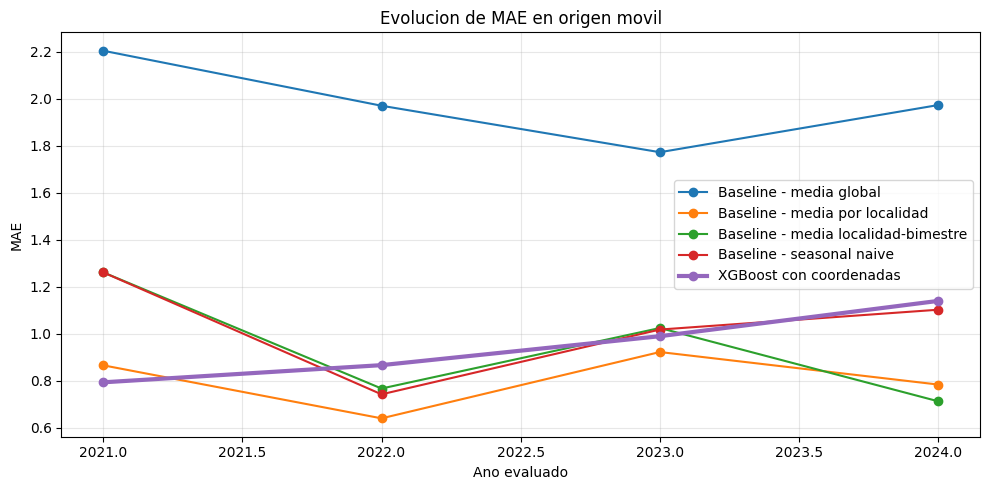

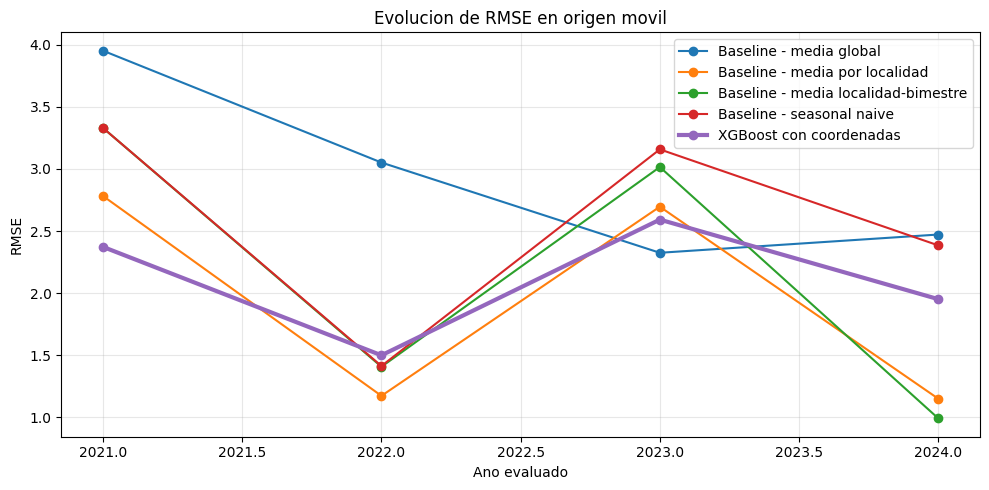

In [6]:
rolling_specs = [
    {"iteracion": 1, "train_years": [2020], "test_year": 2021},
    {"iteracion": 2, "train_years": [2020, 2021], "test_year": 2022},
    {"iteracion": 3, "train_years": [2020, 2021, 2022], "test_year": 2023},
    {"iteracion": 4, "train_years": [2020, 2021, 2022, 2023], "test_year": 2024},
]

rolling_predictions = []
for spec in rolling_specs:
    train_df = df[df[YEAR_COL].isin(spec["train_years"])].copy()
    test_df = df[df[YEAR_COL].eq(spec["test_year"])].copy()
    escenario = f"rolling_{spec['iteracion']}_test_{spec['test_year']}"
    for baseline in baseline_names:
        pred = predict_baseline(train_df, test_df, baseline, escenario)
        pred["iteracion"] = spec["iteracion"]
        pred["historial"] = ",".join(map(str, spec["train_years"]))
        pred["ano_evaluado"] = spec["test_year"]
        rolling_predictions.append(pred)

predicciones_rolling_baselines = pd.concat(rolling_predictions, ignore_index=True)
resultados_baselines_rolling = evaluate_prediction_frame(
    predicciones_rolling_baselines,
    extra_cols=["iteracion", "historial", "ano_evaluado"]
)
resultados_baselines_rolling.to_csv("resultados_baselines_rolling_v10.csv", index=False, encoding="utf-8-sig")
display(resultados_baselines_rolling.sort_values(["iteracion", "RMSE", "MAE"]))

# Comparacion grafica con XGBoost rolling de v8.
xgb_rolling = resultados_rolling_v8[resultados_rolling_v8["modelo"].eq("XGBoost_con_latitud_longitud")].copy()
for metric in ["MAE", "RMSE"]:
    plt.figure(figsize=(10, 5))
    for baseline in baseline_names:
        sub = resultados_baselines_rolling[resultados_baselines_rolling["baseline"].eq(baseline)]
        plt.plot(sub["ano_evaluado"], sub[metric], marker="o", label=BASELINE_LABELS[baseline])
    plt.plot(xgb_rolling["prueba"], xgb_rolling[metric], marker="o", linewidth=3, label="XGBoost con coordenadas")
    plt.xlabel("Ano evaluado")
    plt.ylabel(metric)
    plt.title(f"Evolucion de {metric} en origen movil")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Particion aleatoria descriptiva compatible con v7


In [7]:
# Reproduccion de las mismas filas de test de v7 mediante train_test_split 70/15/15 con random_state=42.
df_random = df_raw.copy()
df_random["_row_id"] = np.arange(len(df_random))
df_random[YEAR_COL] = pd.to_numeric(df_random[YEAR_COL], errors="coerce")
df_random[BIMESTER_COL] = pd.to_numeric(df_random[BIMESTER_COL], errors="coerce")
df_random[TARGET] = pd.to_numeric(df_random[TARGET], errors="coerce")
df_random = df_random[df_random[TARGET].notna()].reset_index(drop=True)
df_random["indice_tiempo"] = (df_random[YEAR_COL] - 2020) * 6 + (df_random[BIMESTER_COL] - 1)

train_idx, temp_idx = train_test_split(df_random.index, test_size=0.30, random_state=RANDOM_STATE)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=RANDOM_STATE)
random_train = df_random.loc[train_idx].copy()
random_test = df_random.loc[test_idx].copy()
assert len(random_train) == 417 and len(random_test) == 90

random_predictions = []
for baseline in baseline_names:
    # Para la particion aleatoria se usa solo el conjunto de entrenamiento. No es evaluacion temporal estricta.
    pred = predict_baseline(
        random_train,
        random_test,
        baseline,
        "particion_aleatoria_v7_descriptiva",
        require_temporal_order=False,
    )
    random_predictions.append(pred)

pred_random_baselines = pd.concat(random_predictions, ignore_index=True)
resultados_random_baselines = evaluate_prediction_frame(pred_random_baselines)

xgb_random_path = Path("comparacion_xgboost_con_sin_espaciales.csv")
rows_random = []
if xgb_random_path.exists():
    xgb_random = pd.read_csv(xgb_random_path)
    xgb_random_test = xgb_random[xgb_random["conjunto"].eq("test")].copy()
    for _, row in xgb_random_test.iterrows():
        rows_random.append({
            "escenario": "particion_aleatoria_v7_descriptiva",
            "baseline": "",
            "modelo_o_baseline": "XGBoost " + row["modelo"],
            "n_registros": int(row.get("n_registros", 90)) if "n_registros" in row else 90,
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "R2": row["R2"],
            "tipo": "modelo",
        })
rand_base = resultados_random_baselines.copy()
rand_base["tipo"] = "baseline"
comparacion_aleatoria_baselines = pd.concat([rand_base, pd.DataFrame(rows_random)], ignore_index=True)
comparacion_aleatoria_baselines.to_csv("comparacion_aleatoria_baselines_v10.csv", index=False, encoding="utf-8-sig")
display(comparacion_aleatoria_baselines.sort_values(["RMSE", "MAE"]))


,escenario,baseline,modelo_o_baseline,n_registros,MAE,RMSE,R2,tipo
4,particion_aleatoria_v7_descriptiva,,XGBoost con_latitud_longitud,90,0.423633,0.746701,0.890315,modelo
2,particion_aleatoria_v7_descriptiva,media_localidad_bimestre,Baseline - media localidad-bimestre,90,0.591423,0.912702,0.836126,baseline
1,particion_aleatoria_v7_descriptiva,media_localidad,Baseline - media por localidad,90,0.583730,0.923548,0.832208,baseline
3,particion_aleatoria_v7_descriptiva,seasonal_naive,Baseline - seasonal naive,90,0.752488,1.543053,0.531603,baseline
5,particion_aleatoria_v7_descriptiva,,XGBoost sin_latitud_longitud,90,1.531498,2.108955,0.125043,modelo
0,particion_aleatoria_v7_descriptiva,media_global,Baseline - media global,90,1.686313,2.256966,-0.002079,baseline


## 9. Baselines compatibles con LOLO


In [8]:
def lolo_baselines(exclude_sumapaz=False):
    data = df.copy()
    scenario = "LOLO_sin_sumapaz" if exclude_sumapaz else "LOLO_todas_las_localidades"
    if exclude_sumapaz:
        data = data[data[LOCALITY_COL] != "SUMAPAZ"].copy()
    localidades = sorted(data[LOCALITY_COL].dropna().unique())
    rows = []
    preds = []
    for loc_test in localidades:
        mask_test = data[LOCALITY_COL].eq(loc_test)
        test_df = data.loc[mask_test].copy()
        rest_df = data.loc[~mask_test].copy()
        rest_idx = rest_df.index.to_numpy()
        train_idx, val_idx = train_test_split(rest_idx, test_size=0.20, random_state=RANDOM_STATE)
        train_df = data.loc[train_idx].copy()
        assert train_df[LOCALITY_COL].nunique() == len(localidades) - 1
        assert loc_test not in set(train_df[LOCALITY_COL])
        assert len(test_df) in [26, 30] or loc_test == "SUMAPAZ"
        for baseline in ["media_global", "media_bimestre"]:
            # Compatible con localidad no observada: no se usa media de localidad excluida.
            stats = build_history_stats(train_df)
            base = test_df[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL, "indice_tiempo", TARGET]].copy()
            base = base.rename(columns={LOCALITY_COL: "localidad", YEAR_COL: "ano", BIMESTER_COL: "bimestre", TARGET: "valor_real"})
            pred_values, rules, levels = [], [], []
            for _, row in base.iterrows():
                if baseline == "media_global":
                    pred_values.append(stats["global"])
                    rules.append("media_global_localidades_entrenamiento")
                    levels.append(0)
                else:
                    bim = get_value(stats["bimestre"], row["bimestre"])
                    if pd.notna(bim):
                        pred_values.append(bim)
                        rules.append("media_bimestre_localidades_entrenamiento")
                        levels.append(0)
                    else:
                        pred_values.append(stats["global"])
                        rules.append("fallback_media_global")
                        levels.append(1)
            base["baseline"] = baseline
            base["modelo_o_baseline"] = BASELINE_LABELS[baseline]
            base["escenario"] = scenario
            base["prediccion"] = pred_values
            base["regla_utilizada"] = rules
            base["nivel_fallback"] = levels
            base["uso_fallback"] = base["nivel_fallback"] > 0
            base["localidad_test"] = loc_test
            base["error"] = base["valor_real"] - base["prediccion"]
            base["error_absoluto"] = base["error"].abs()
            preds.append(base)
            met = metrics_original(base["valor_real"], base["prediccion"])
            rows.append({
                "escenario": scenario,
                "localidad_test": loc_test,
                "baseline": baseline,
                "modelo_o_baseline": BASELINE_LABELS[baseline],
                "n_train": len(train_df),
                "n_test": len(test_df),
                **met,
            })
    return pd.DataFrame(rows), pd.concat(preds, ignore_index=True)

lolo_all_results, lolo_all_preds = lolo_baselines(exclude_sumapaz=False)
lolo_no_sum_results, lolo_no_sum_preds = lolo_baselines(exclude_sumapaz=True)
resultados_baselines_lolo = pd.concat([lolo_all_results, lolo_no_sum_results], ignore_index=True)
predicciones_baselines_lolo = pd.concat([lolo_all_preds, lolo_no_sum_preds], ignore_index=True)
resultados_baselines_lolo.to_csv("resultados_baselines_lolo_v10.csv", index=False, encoding="utf-8-sig")

lolo_summary = resultados_baselines_lolo.groupby(["escenario", "baseline", "modelo_o_baseline"])[["MAE", "RMSE", "R2"]].mean().reset_index()
display(lolo_summary)


,escenario,baseline,modelo_o_baseline,MAE,RMSE,R2
0,LOLO_sin_sumapaz,media_bimestre,Baseline - media por bimestre,1.553282,1.684063,-11.127891
1,LOLO_sin_sumapaz,media_global,Baseline - media global,1.558917,1.711239,-11.286270
2,LOLO_todas_las_localidades,media_bimestre,Baseline - media por bimestre,2.028960,2.277109,-14.382694
3,LOLO_todas_las_localidades,media_global,Baseline - media global,2.042525,2.298398,-14.385604


## 10. Fallbacks, hipotesis y graficas


,fuente,escenario,baseline,modelo_o_baseline,regla_utilizada,nivel_fallback,uso_fallback,n_predicciones,porcentaje
0,LOLO,LOLO_sin_sumapaz,media_bimestre,Baseline - media por bimestre,media_bimestre_localidades_entrenamiento,0,False,570,100.000000
1,LOLO,LOLO_sin_sumapaz,media_global,Baseline - media global,media_global_localidades_entrenamiento,0,False,570,100.000000
2,LOLO,LOLO_todas_las_localidades,media_bimestre,Baseline - media por bimestre,media_bimestre_localidades_entrenamiento,0,False,596,100.000000
3,LOLO,LOLO_todas_las_localidades,media_global,Baseline - media global,media_global_localidades_entrenamiento,0,False,596,100.000000
4,aleatoria_descriptiva,particion_aleatoria_v7_descriptiva,media_global,Baseline - media global,media_global,0,False,90,100.000000
5,aleatoria_descriptiva,particion_aleatoria_v7_descriptiva,media_localidad,Baseline - media por localidad,media_localidad,0,False,90,100.000000
6,aleatoria_descriptiva,particion_aleatoria_v7_descriptiva,media_localidad_bimestre,Baseline - media localidad-bimestre,media_localidad_bimestre,0,False,90,100.000000
7,aleatoria_descriptiva,particion_aleatoria_v7_descriptiva,seasonal_naive,Baseline - seasonal naive,fallback_media_localidad_bimestre,1,True,35,38.888889
8,aleatoria_descriptiva,particion_aleatoria_v7_descriptiva,seasonal_naive,Baseline - seasonal naive,seasonal_naive_anio_anterior,0,False,55,61.111111
9,rolling_origin,rolling_1_test_2021,media_global,Baseline - media global,media_global,0,False,120,100.000000


,esquema,estado,mejor_modelo,mejor_baseline,nota
0,Validacion temporal 2024,No respaldada,XGBoost - con_latitud_longitud,Baseline - media localidad-bimestre,Comparacion principal sobre 117 registros de 2...
1,Origen movil,No respaldada,XGBoost_con_latitud_longitud,Baseline - media por localidad,Comparacion con promedios de cuatro iteracione...
2,Particion aleatoria,Respaldada,XGBoost con_latitud_longitud,Baseline - media localidad-bimestre,Comparacion descriptiva; mezcla anos y no prue...
3,LOLO todas las localidades,No respaldada,XGBoost_LOLO,Baseline - media por bimestre,Baselines compatibles con localidad no observa...
4,LOLO sin Sumapaz,Parcialmente respaldada,XGBoost_LOLO,Baseline - media por bimestre,Baselines compatibles con localidad no observa...


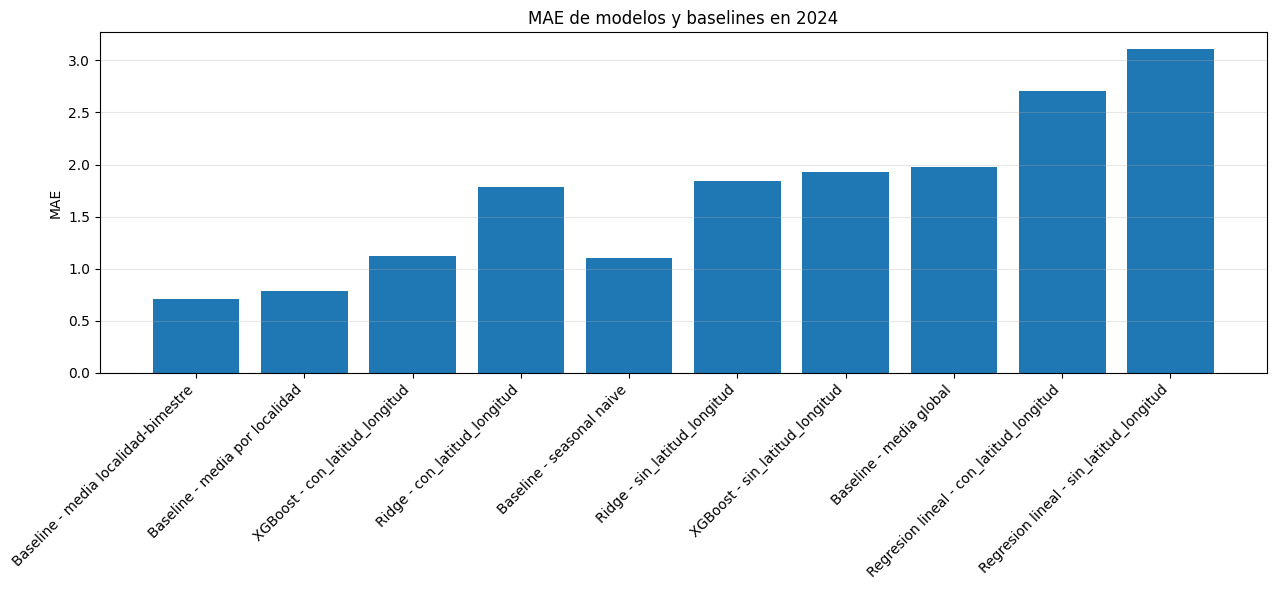

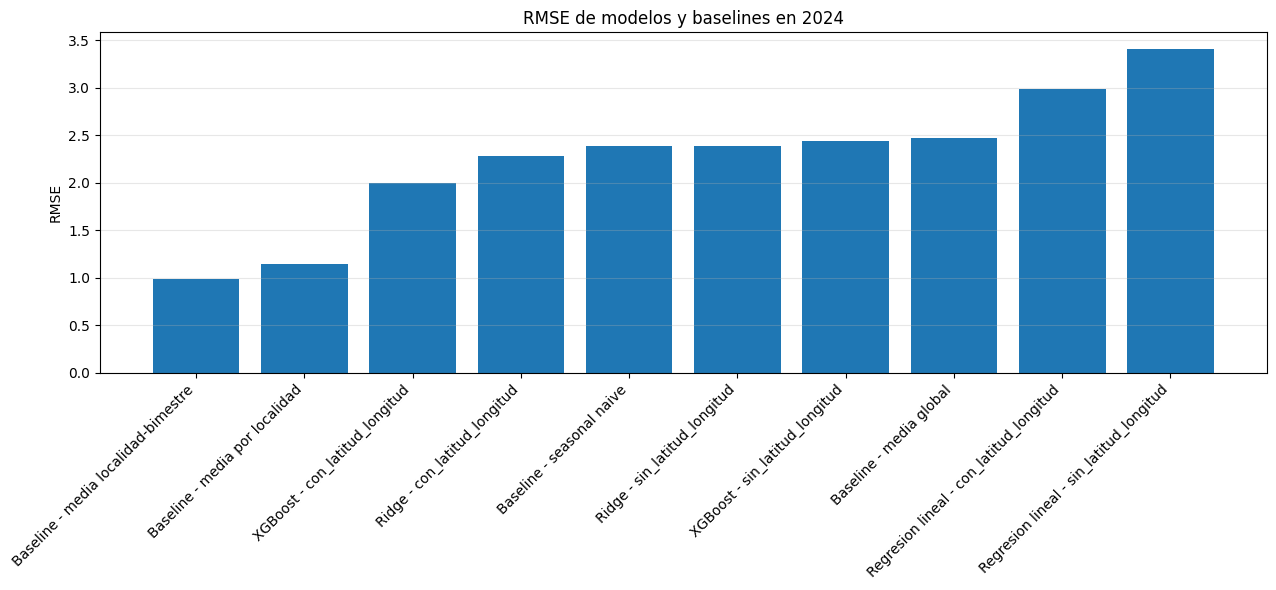

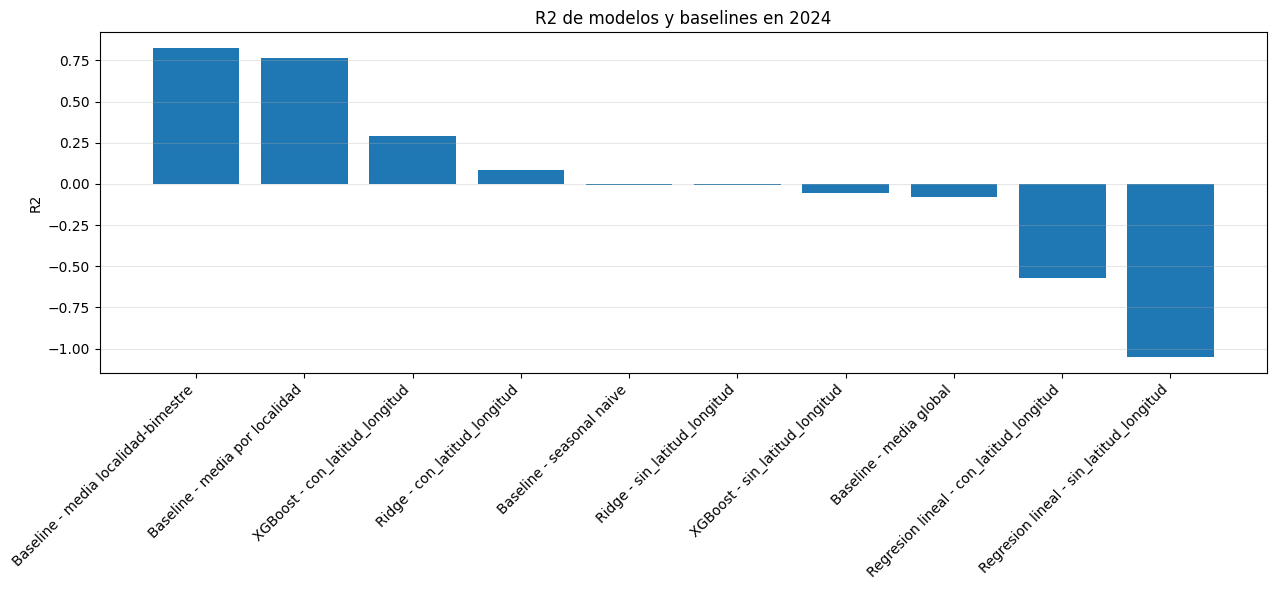

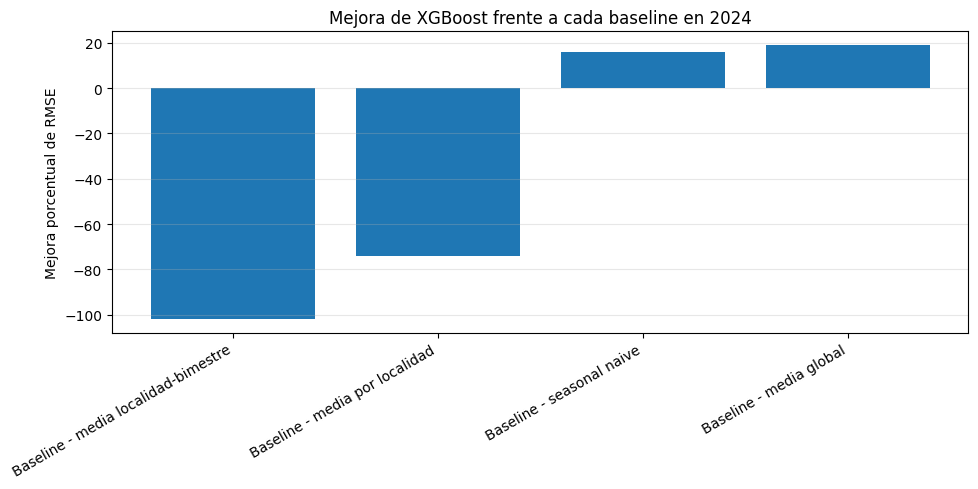

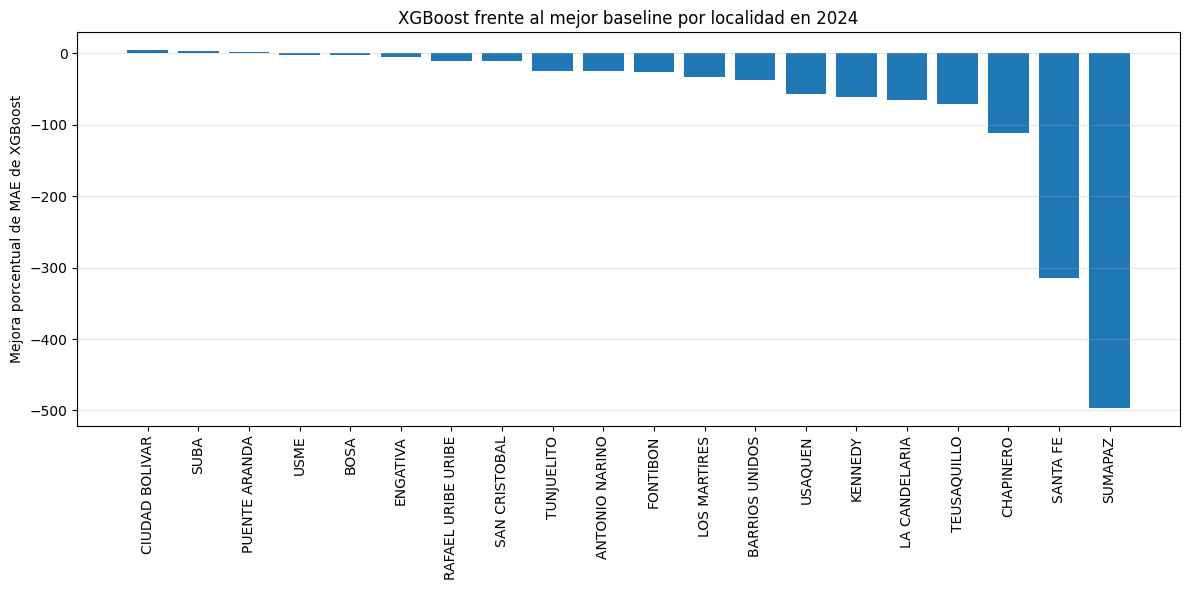

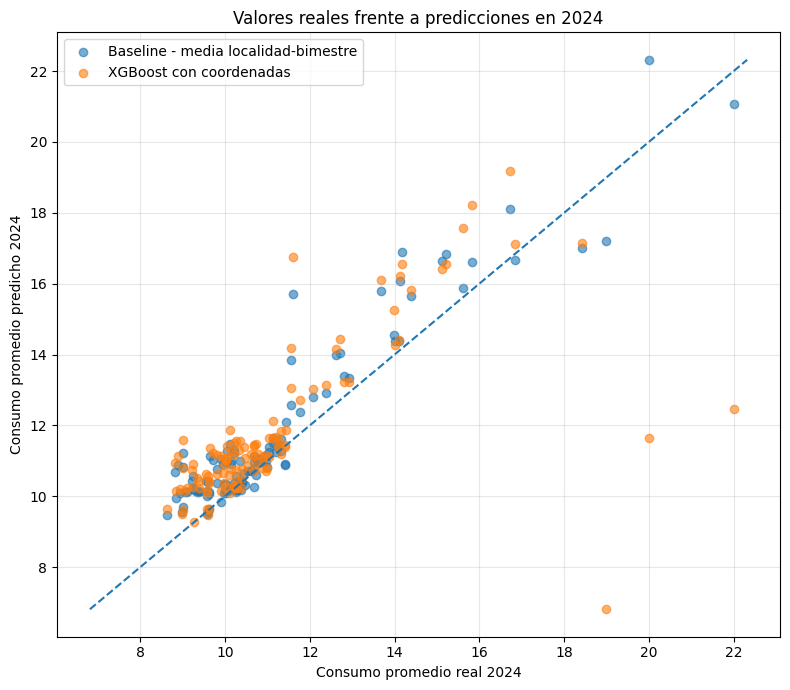

In [9]:
fallback_sources = [
    predicciones_baselines_2023_2024.assign(fuente="temporal_2023_2024"),
    predicciones_rolling_baselines.assign(fuente="rolling_origin"),
    pred_random_baselines.assign(fuente="aleatoria_descriptiva"),
    predicciones_baselines_lolo.assign(fuente="LOLO"),
]
fallback_all = pd.concat(fallback_sources, ignore_index=True, sort=False)
resumen_uso_fallbacks = (
    fallback_all
    .groupby(["fuente", "escenario", "baseline", "modelo_o_baseline", "regla_utilizada", "nivel_fallback", "uso_fallback"], dropna=False)
    .size()
    .rename("n_predicciones")
    .reset_index()
)
totals = resumen_uso_fallbacks.groupby(["fuente", "escenario", "baseline"])["n_predicciones"].transform("sum")
resumen_uso_fallbacks["porcentaje"] = 100 * resumen_uso_fallbacks["n_predicciones"] / totals
resumen_uso_fallbacks.to_csv("resumen_uso_fallbacks_v10.csv", index=False, encoding="utf-8-sig")
display(resumen_uso_fallbacks.head(30))

# Evaluacion de hipotesis por esquema.
def classify_hypothesis(best_model_rmse, best_model_mae, best_baseline_rmse, best_baseline_mae, condition_note):
    if best_model_rmse < best_baseline_rmse and best_model_mae < best_baseline_mae:
        return "Respaldada", condition_note
    if best_model_rmse < best_baseline_rmse or best_model_mae < best_baseline_mae:
        return "Parcialmente respaldada", condition_note
    return "No respaldada", condition_note

hip_rows = []
# Temporal 2024.
best_model_2024 = modelos_2024.sort_values(["RMSE", "MAE"]).iloc[0]
estado, nota = classify_hypothesis(best_model_2024["RMSE"], best_model_2024["MAE"], best_rmse, best_mae, "Comparacion principal sobre 117 registros de 2024.")
hip_rows.append({"esquema": "Validacion temporal 2024", "estado": estado, "mejor_modelo": best_model_2024["modelo_o_baseline"], "mejor_baseline": best_baseline_name, "nota": nota})

# Rolling origin: comparar promedio XGBoost con coordenadas contra mejor baseline promedio por RMSE.
rolling_avg_baseline = resultados_baselines_rolling.groupby(["baseline", "modelo_o_baseline"])[["MAE", "RMSE", "R2"]].mean().reset_index()
best_roll_base = rolling_avg_baseline.sort_values(["RMSE", "MAE"]).iloc[0]
xgb_roll = resultados_rolling_v8[resultados_rolling_v8["modelo"].eq("XGBoost_con_latitud_longitud")][["MAE", "RMSE"]].mean()
estado, nota = classify_hypothesis(xgb_roll["RMSE"], xgb_roll["MAE"], best_roll_base["RMSE"], best_roll_base["MAE"], "Comparacion con promedios de cuatro iteraciones de origen movil.")
hip_rows.append({"esquema": "Origen movil", "estado": estado, "mejor_modelo": "XGBoost_con_latitud_longitud", "mejor_baseline": best_roll_base["modelo_o_baseline"], "nota": nota})

# Aleatoria descriptiva.
rand_models = comparacion_aleatoria_baselines[comparacion_aleatoria_baselines["tipo"].eq("modelo")]
rand_bases = comparacion_aleatoria_baselines[comparacion_aleatoria_baselines["tipo"].eq("baseline")]
best_rand_model = rand_models.sort_values(["RMSE", "MAE"]).iloc[0]
best_rand_base = rand_bases.sort_values(["RMSE", "MAE"]).iloc[0]
estado, nota = classify_hypothesis(best_rand_model["RMSE"], best_rand_model["MAE"], best_rand_base["RMSE"], best_rand_base["MAE"], "Comparacion descriptiva; mezcla anos y no prueba generalizacion temporal estricta.")
hip_rows.append({"esquema": "Particion aleatoria", "estado": estado, "mejor_modelo": best_rand_model["modelo_o_baseline"], "mejor_baseline": best_rand_base["modelo_o_baseline"], "nota": nota})

# LOLO todas y sin Sumapaz.
for scenario, xgb_df in [
    ("LOLO todas las localidades", resultados_lolo_v6),
    ("LOLO sin Sumapaz", resultados_lolo_sin_sumapaz_v6),
]:
    scenario_key = "LOLO_todas_las_localidades" if "todas" in scenario else "LOLO_sin_sumapaz"
    base_summary = resultados_baselines_lolo[resultados_baselines_lolo["escenario"].eq(scenario_key)].groupby(["baseline", "modelo_o_baseline"])[["MAE", "RMSE"]].mean().reset_index()
    best_lolo_base = base_summary.sort_values(["RMSE", "MAE"]).iloc[0]
    xgb_mean = xgb_df[["MAE_test", "RMSE_test"]].mean()
    estado, nota = classify_hypothesis(xgb_mean["RMSE_test"], xgb_mean["MAE_test"], best_lolo_base["RMSE"], best_lolo_base["MAE"], "Baselines compatibles con localidad no observada: media global y media por bimestre.")
    hip_rows.append({"esquema": scenario, "estado": estado, "mejor_modelo": "XGBoost_LOLO", "mejor_baseline": best_lolo_base["modelo_o_baseline"], "nota": nota})

evaluacion_hipotesis = pd.DataFrame(hip_rows)
evaluacion_hipotesis.to_csv("evaluacion_hipotesis_v10.csv", index=False, encoding="utf-8-sig")
display(evaluacion_hipotesis)

# Graficas principales.
for metric in ["MAE", "RMSE", "R2"]:
    plot_df = comparacion_2024.sort_values(["RMSE", "MAE"]).copy()
    plt.figure(figsize=(13, 6))
    plt.bar(plot_df["modelo_o_baseline"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} de modelos y baselines en 2024")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

xgb_improvements = mejoras_relativas_modelos[mejoras_relativas_modelos["modelo"].str.contains("XGBoost - con_latitud_longitud")].copy()
plt.figure(figsize=(10, 5))
plt.bar(xgb_improvements["baseline_referencia"], xgb_improvements["mejora_RMSE_porcentaje"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mejora porcentual de RMSE")
plt.title("Mejora de XGBoost frente a cada baseline en 2024")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
loc_plot = comparacion_xgboost_baseline_por_localidad.sort_values("mejora_porcentual_xgboost", ascending=False)
plt.bar(loc_plot["localidad"], loc_plot["mejora_porcentual_xgboost"])
plt.xticks(rotation=90)
plt.ylabel("Mejora porcentual de MAE de XGBoost")
plt.title("XGBoost frente al mejor baseline por localidad en 2024")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Reales vs predichos: mejor baseline y XGBoost.
plt.figure(figsize=(8, 7))
plt.scatter(pred_best_baseline_2024["valor_real"], pred_best_baseline_2024["prediccion"], alpha=0.6, label=best_baseline_name)
plt.scatter(pred_xgb_2024["valor_real"], pred_xgb_2024["prediccion"], alpha=0.6, label="XGBoost con coordenadas")
min_v = min(pred_best_baseline_2024["valor_real"].min(), pred_best_baseline_2024["prediccion"].min(), pred_xgb_2024["prediccion"].min())
max_v = max(pred_best_baseline_2024["valor_real"].max(), pred_best_baseline_2024["prediccion"].max(), pred_xgb_2024["prediccion"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Consumo promedio real 2024")
plt.ylabel("Consumo promedio predicho 2024")
plt.title("Valores reales frente a predicciones en 2024")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Sintesis academica y texto propuesto para la tesis


In [10]:
def markdown_table(df_in, cols):
    tmp = df_in[cols].copy()
    for c in cols:
        if c in tmp.columns and pd.api.types.is_numeric_dtype(tmp[c]):
            tmp[c] = tmp[c].map(lambda x: f"{x:.4f}")
    header = "| " + " | ".join(cols) + " |"
    sep = "| " + " | ".join(["---"] * len(cols)) + " |"
    body = ["| " + " | ".join(str(v) for v in row) + " |" for row in tmp.to_numpy()]
    return "\n".join([header, sep] + body)

temporal_table = resultados_baselines_temporales.sort_values(["escenario", "RMSE", "MAE"])
model_table = comparacion_2024.sort_values("ranking")[["ranking", "modelo_o_baseline", "tipo", "MAE", "RMSE", "R2", "mejora_RMSE_porcentaje"]]
loc_counts = comparacion_xgboost_baseline_por_localidad["resultado"].value_counts().to_dict()
xgb_best_improvement = mejoras_relativas_modelos[
    (mejoras_relativas_modelos["modelo"].eq("XGBoost - con_latitud_longitud")) &
    (mejoras_relativas_modelos["es_mejor_baseline"].eq(True))
].iloc[0]

texto = f'''
### Sintesis de resultados v10

Los baselines temporales fueron calculados sin usar informacion del ano evaluado. Para 2023 se uso exclusivamente 2020-2022 y para 2024 se uso 2020-2023. Los resultados de referencia fueron:

{markdown_table(temporal_table, ["escenario", "modelo_o_baseline", "n_registros", "MAE", "RMSE", "R2"])}

En 2024, el mejor baseline segun RMSE fue {best_baseline_name}, con MAE={best_mae:.4f}, RMSE={best_rmse:.4f} y R2={best_r2:.4f}. La comparacion principal fue:

{markdown_table(model_table, ["ranking", "modelo_o_baseline", "tipo", "MAE", "RMSE", "R2", "mejora_RMSE_porcentaje"])}

XGBoost con coordenadas obtuvo una mejora de MAE de {xgb_best_improvement["mejora_MAE_porcentaje"]:.2f}% y una mejora de RMSE de {xgb_best_improvement["mejora_RMSE_porcentaje"]:.2f}% frente al mejor baseline. La comparacion por localidad mostro la siguiente distribucion: {loc_counts}. Esta heterogeneidad indica que el resultado global no debe generalizarse sin revisar diferencias territoriales.

La evaluacion de hipotesis fue:

{markdown_table(evaluacion_hipotesis, ["esquema", "estado", "mejor_modelo", "mejor_baseline", "nota"])}

Texto propuesto para objetivos: "La investigacion incorpora modelos predictivos y modelos de referencia para evaluar si las tecnicas de Machine Learning reducen el error respecto a estrategias simples basadas en promedios historicos y seasonal naive."

Texto propuesto para hipotesis: "La hipotesis sobre mejor desempeno de modelos de Machine Learning se evalua de forma comparativa frente a baselines y se interpreta por separado para particion aleatoria, validacion temporal, origen movil y validacion espacial."

Texto propuesto para diseno de modelos: "Ademas de XGBoost, regresion lineal y Ridge, se implementaron referencias triviales: media global, media historica por localidad, media historica por localidad-bimestre y seasonal naive. Cada baseline se construyo solamente con el historial permitido."

Texto propuesto para validacion: "La prueba temporal final de 2024 compara modelos y baselines sobre las mismas 117 observaciones. Las mejoras relativas se calcularon como reduccion porcentual de MAE y RMSE frente a cada baseline, y la diferencia de R2 se reporto como resta simple."

Texto propuesto para resultados: "No se presenta el desempeno de Machine Learning como aporte automatico. Se reporta la reduccion del error frente al mejor baseline y frente a cada referencia individual."

Texto propuesto para discusion: "La superioridad relativa del modelo depende del esquema de validacion. Una mejora en particion aleatoria no equivale a evidencia suficiente de generalizacion temporal o espacial."

Texto propuesto para conclusiones: "La evidencia de la hipotesis debe clasificarse segun el esquema evaluado. El desempeno favorable de un modelo frente a algunos baselines no implica por si solo que la hipotesis quede respaldada en todos los escenarios."

Texto propuesto para limitaciones: "Las variables operativas directamente relacionadas con la construccion del consumo promedio fueron excluidas para reducir el riesgo de fuga de informacion. Sin embargo, las variables climaticas corresponden al mismo periodo bimestral de la variable objetivo, por lo que el escenario temporal se interpreta como estimacion con covariables contemporaneas conocidas y no necesariamente como pronostico anticipado."
'''
display(Markdown(texto))



### Sintesis de resultados v10

Los baselines temporales fueron calculados sin usar informacion del ano evaluado. Para 2023 se uso exclusivamente 2020-2022 y para 2024 se uso 2020-2023. Los resultados de referencia fueron:

| escenario | modelo_o_baseline | n_registros | MAE | RMSE | R2 |
| --- | --- | --- | --- | --- | --- |
| prueba_2024 | Baseline - media localidad-bimestre | 117.0000 | 0.7131 | 0.9911 | 0.8266 |
| prueba_2024 | Baseline - media por localidad | 117.0000 | 0.7843 | 1.1494 | 0.7668 |
| prueba_2024 | Baseline - seasonal naive | 117.0000 | 1.1027 | 2.3843 | -0.0035 |
| prueba_2024 | Baseline - media global | 117.0000 | 1.9732 | 2.4716 | -0.0783 |
| validacion_2023 | Baseline - media global | 120.0000 | 1.7726 | 2.3247 | -0.0341 |
| validacion_2023 | Baseline - media por localidad | 120.0000 | 0.9227 | 2.6958 | -0.3907 |
| validacion_2023 | Baseline - media localidad-bimestre | 120.0000 | 1.0249 | 3.0152 | -0.7398 |
| validacion_2023 | Baseline - seasonal naive | 120.0000 | 1.0183 | 3.1577 | -0.9081 |

En 2024, el mejor baseline segun RMSE fue Baseline - media localidad-bimestre, con MAE=0.7131, RMSE=0.9911 y R2=0.8266. La comparacion principal fue:

| ranking | modelo_o_baseline | tipo | MAE | RMSE | R2 | mejora_RMSE_porcentaje |
| --- | --- | --- | --- | --- | --- | --- |
| 1.0000 | Baseline - media localidad-bimestre | baseline | 0.7131 | 0.9911 | 0.8266 | 0.0000 |
| 2.0000 | Baseline - media por localidad | baseline | 0.7843 | 1.1494 | 0.7668 | -15.9730 |
| 3.0000 | XGBoost - con_latitud_longitud | modelo | 1.1212 | 2.0006 | 0.2935 | -101.8661 |
| 4.0000 | Ridge - con_latitud_longitud | modelo | 1.7856 | 2.2808 | 0.0818 | -130.1295 |
| 5.0000 | Baseline - seasonal naive | baseline | 1.1027 | 2.3843 | -0.0035 | -140.5764 |
| 6.0000 | Ridge - sin_latitud_longitud | modelo | 1.8466 | 2.3844 | -0.0036 | -140.5921 |
| 7.0000 | XGBoost - sin_latitud_longitud | modelo | 1.9315 | 2.4433 | -0.0537 | -146.5268 |
| 8.0000 | Baseline - media global | baseline | 1.9732 | 2.4716 | -0.0783 | -149.3890 |
| 9.0000 | Regresion lineal - con_latitud_longitud | modelo | 2.7092 | 2.9824 | -0.5700 | -200.9216 |
| 10.0000 | Regresion lineal - sin_latitud_longitud | modelo | 3.1139 | 3.4107 | -1.0533 | -244.1401 |

XGBoost con coordenadas obtuvo una mejora de MAE de -57.22% y una mejora de RMSE de -101.87% frente al mejor baseline. La comparacion por localidad mostro la siguiente distribucion: {'Baseline supera a XGBoost': 14, 'Resultado similar': 6}. Esta heterogeneidad indica que el resultado global no debe generalizarse sin revisar diferencias territoriales.

La evaluacion de hipotesis fue:

| esquema | estado | mejor_modelo | mejor_baseline | nota |
| --- | --- | --- | --- | --- |
| Validacion temporal 2024 | No respaldada | XGBoost - con_latitud_longitud | Baseline - media localidad-bimestre | Comparacion principal sobre 117 registros de 2024. |
| Origen movil | No respaldada | XGBoost_con_latitud_longitud | Baseline - media por localidad | Comparacion con promedios de cuatro iteraciones de origen movil. |
| Particion aleatoria | Respaldada | XGBoost con_latitud_longitud | Baseline - media localidad-bimestre | Comparacion descriptiva; mezcla anos y no prueba generalizacion temporal estricta. |
| LOLO todas las localidades | No respaldada | XGBoost_LOLO | Baseline - media por bimestre | Baselines compatibles con localidad no observada: media global y media por bimestre. |
| LOLO sin Sumapaz | Parcialmente respaldada | XGBoost_LOLO | Baseline - media por bimestre | Baselines compatibles con localidad no observada: media global y media por bimestre. |

Texto propuesto para objetivos: "La investigacion incorpora modelos predictivos y modelos de referencia para evaluar si las tecnicas de Machine Learning reducen el error respecto a estrategias simples basadas en promedios historicos y seasonal naive."

Texto propuesto para hipotesis: "La hipotesis sobre mejor desempeno de modelos de Machine Learning se evalua de forma comparativa frente a baselines y se interpreta por separado para particion aleatoria, validacion temporal, origen movil y validacion espacial."

Texto propuesto para diseno de modelos: "Ademas de XGBoost, regresion lineal y Ridge, se implementaron referencias triviales: media global, media historica por localidad, media historica por localidad-bimestre y seasonal naive. Cada baseline se construyo solamente con el historial permitido."

Texto propuesto para validacion: "La prueba temporal final de 2024 compara modelos y baselines sobre las mismas 117 observaciones. Las mejoras relativas se calcularon como reduccion porcentual de MAE y RMSE frente a cada baseline, y la diferencia de R2 se reporto como resta simple."

Texto propuesto para resultados: "No se presenta el desempeno de Machine Learning como aporte automatico. Se reporta la reduccion del error frente al mejor baseline y frente a cada referencia individual."

Texto propuesto para discusion: "La superioridad relativa del modelo depende del esquema de validacion. Una mejora en particion aleatoria no equivale a evidencia suficiente de generalizacion temporal o espacial."

Texto propuesto para conclusiones: "La evidencia de la hipotesis debe clasificarse segun el esquema evaluado. El desempeno favorable de un modelo frente a algunos baselines no implica por si solo que la hipotesis quede respaldada en todos los escenarios."

Texto propuesto para limitaciones: "Las variables operativas directamente relacionadas con la construccion del consumo promedio fueron excluidas para reducir el riesgo de fuga de informacion. Sin embargo, las variables climaticas corresponden al mismo periodo bimestral de la variable objetivo, por lo que el escenario temporal se interpreta como estimacion con covariables contemporaneas conocidas y no necesariamente como pronostico anticipado."


## 12. Verificacion final


In [11]:
required_csvs = [
    "resultados_baselines_temporales_v10.csv",
    "predicciones_baselines_2023_2024_v10.csv",
    "resultados_baselines_rolling_v10.csv",
    "resumen_uso_fallbacks_v10.csv",
    "comparacion_modelos_baselines_2024_v10.csv",
    "mejoras_relativas_modelos_v10.csv",
    "comparacion_xgboost_baseline_por_localidad_v10.csv",
    "evaluacion_hipotesis_v10.csv",
    "resultados_baselines_lolo_v10.csv",
    "comparacion_aleatoria_baselines_v10.csv",
]
for path in required_csvs:
    print(path, "OK" if Path(path).exists() else "NO")
    assert Path(path).exists()

assert set(predicciones_baselines_2023_2024[predicciones_baselines_2023_2024["escenario"].eq("prueba_2024")]["ano"].unique()) == {2024}
assert not predicciones_baselines_2023_2024["prediccion"].isna().any()
assert np.allclose(
    mejoras_relativas_modelos["mejora_MAE"],
    1 - mejoras_relativas_modelos["MAE_modelo"] / mejoras_relativas_modelos["MAE_baseline"]
)
assert np.allclose(
    mejoras_relativas_modelos["mejora_RMSE"],
    1 - mejoras_relativas_modelos["RMSE_modelo"] / mejoras_relativas_modelos["RMSE_baseline"]
)
assert np.allclose(
    mejoras_relativas_modelos["diferencia_R2"],
    mejoras_relativas_modelos["R2_modelo"] - mejoras_relativas_modelos["R2_baseline"]
)

expected_hashes = {
    "predic_consumo_agua.ipynb": "1ADF3CC3EEB35F15256C4EA58C3CF0FF4048BB97D655735B34F9FD39263E38EB",
    "predic_consumo_agua_v2.ipynb": "18CBC8F73BB1ACE3DBC391FDA5F3E1BD373459F4F5AC48F662E034FE40DFDB60",
    "predic_consumo_agua_v3.ipynb": "52F9F75781D6714CB8841E84958C639CD3DACC4DFB649092D8E94FBF16385F0D",
    "predic_consumo_agua_v4.ipynb": "EDA0A1F25A0F4934E66FDB85D85134CAD0C46119E07F20F4741C6D7E14E7A31E",
    "predic_consumo_agua_v5.ipynb": "C5BEAAFA7590CE114F8B5BC4913F1B69A0819CC78009212E4D77FDFAEB044890",
    "predic_consumo_agua_v6.ipynb": "2E52F31545F6E2EBB27E7430FD20A0A4838862AF1353970E2AF4503D80054E7C",
    "predic_consumo_agua_v7.ipynb": "7793E98532CE6EB4E74D98BD648707D2B422FE1B2F7988D447D2863A2FC89932",
    "predic_consumo_agua_v8.ipynb": "A7394F0374DD3078A3A849C9E64652BDC33E4633403004047CC9F7ACC4AAE4DF",
    "predic_consumo_agua_v9.ipynb": "056FF757377AB742509F25B226441B390895D7710DA5D405E6C3BC57A5BE3283",
}
for filename, expected in expected_hashes.items():
    actual = hashlib.sha256(Path(filename).read_bytes()).hexdigest().upper()
    assert actual == expected, f"Notebook previo modificado: {filename}"

print("\nVerificaciones finales superadas:")
print(" - Todas las metricas estan en escala original.")
print(" - Los baselines temporales usan solo datos anteriores.")
print(" - Seasonal naive fue verificado con diferencia exacta de seis bimestres cuando aplica.")
print(" - Fallbacks documentados por prediccion.")
print(" - Modelos y baselines 2024 usan las mismas 117 observaciones.")
print(" - Mejoras relativas calculadas correctamente.")
print(" - Notebooks v1-v9 permanecen sin modificaciones.")


resultados_baselines_temporales_v10.csv OK
predicciones_baselines_2023_2024_v10.csv OK
resultados_baselines_rolling_v10.csv OK
resumen_uso_fallbacks_v10.csv OK
comparacion_modelos_baselines_2024_v10.csv OK
mejoras_relativas_modelos_v10.csv OK
comparacion_xgboost_baseline_por_localidad_v10.csv OK
evaluacion_hipotesis_v10.csv OK
resultados_baselines_lolo_v10.csv OK
comparacion_aleatoria_baselines_v10.csv OK

Verificaciones finales superadas:
 - Todas las metricas estan en escala original.
 - Los baselines temporales usan solo datos anteriores.
 - Seasonal naive fue verificado con diferencia exacta de seis bimestres cuando aplica.
 - Fallbacks documentados por prediccion.
 - Modelos y baselines 2024 usan las mismas 117 observaciones.
 - Mejoras relativas calculadas correctamente.
 - Notebooks v1-v9 permanecen sin modificaciones.
